# Практическая работа № 1
## Первичный анализ датасета Tips

Выполнил: Эркинбеков Айман  
**Вариант:** B

### Цель работы

Настроить Python, загрузить данные Tips и посмотреть, что в них есть.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [2]:
DATA_PATH = Path("../data/tips.csv")

assert DATA_PATH.exists(), f"Файл не найден: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
rows, columns = df.shape

print(f"Количество строк: {rows}")
print(f"Количество столбцов: {columns}")
print(f"Размер таблицы: {df.shape}")

Количество строк: 244
Количество столбцов: 7
Размер таблицы: (244, 7)


In [4]:
column_types = df.dtypes.to_frame(name="Тип данных")
display(column_types)

df.info()

,Тип данных
total_bill,float64
tip,float64
sex,str
smoker,str
day,str
time,str
size,int64


<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [5]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Количество пропусков": missing_count,
    "Доля пропусков, %": missing_percent
})

display(missing_table)

,Количество пропусков,"Доля пропусков, %"
total_bill,0,0.0
tip,0,0.0
sex,0,0.0
smoker,0,0.0
day,0,0.0
time,0,0.0
size,0,0.0


In [6]:
statistics = df.describe(include="all").T
display(statistics)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_bill,244.0,NaN,NaN,NaN,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,NaN,NaN,NaN,2.998279,1.383638,1.0,2.0,2.9,3.5625,10.0
sex,244,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,244,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,244,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,244,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,244.0,NaN,NaN,NaN,2.569672,0.9511,1.0,2.0,2.0,3.0,6.0


In [7]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Количество пропусков": missing_count,
    "Доля пропусков, %": missing_percent
})

display(missing_table)

,Количество пропусков,"Доля пропусков, %"
total_bill,0,0.0
tip,0,0.0
sex,0,0.0
smoker,0,0.0
day,0,0.0
time,0,0.0
size,0,0.0


## Графики

### Распределение суммы счёта

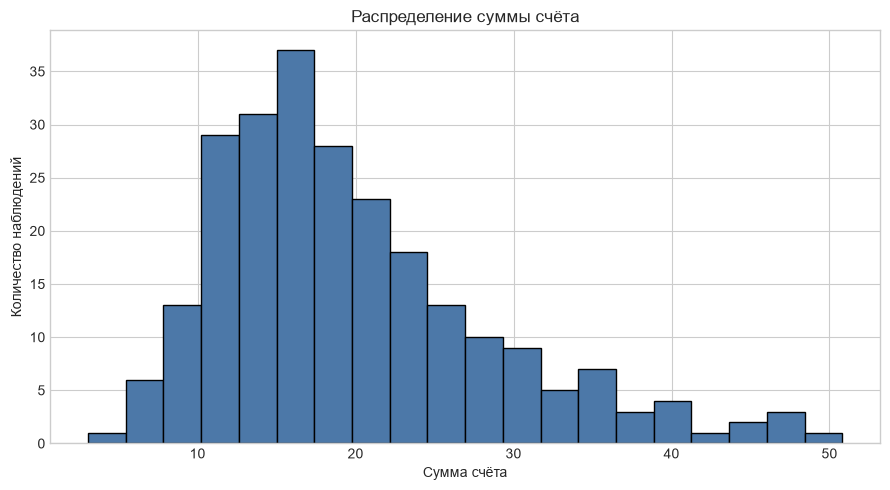

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df["total_bill"].dropna(),
    bins=20,
    color="#4C78A8",
    edgecolor="black"
)

ax.set_title("Распределение суммы счёта")
ax.set_xlabel("Сумма счёта")
ax.set_ylabel("Количество наблюдений")

plt.tight_layout()
plt.show()

### Количество посещений по дням недели

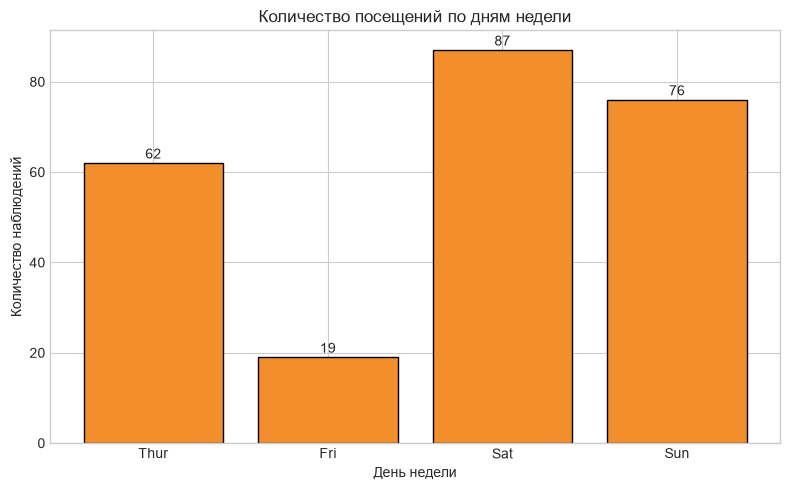

In [9]:
day_order = ["Thur", "Fri", "Sat", "Sun"]
day_counts = df["day"].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    day_counts.index,
    day_counts.values,
    color="#F28E2B",
    edgecolor="black"
)

ax.set_title("Количество посещений по дням недели")
ax.set_xlabel("День недели")
ax.set_ylabel("Количество наблюдений")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha="center"
    )

plt.tight_layout()
plt.show()

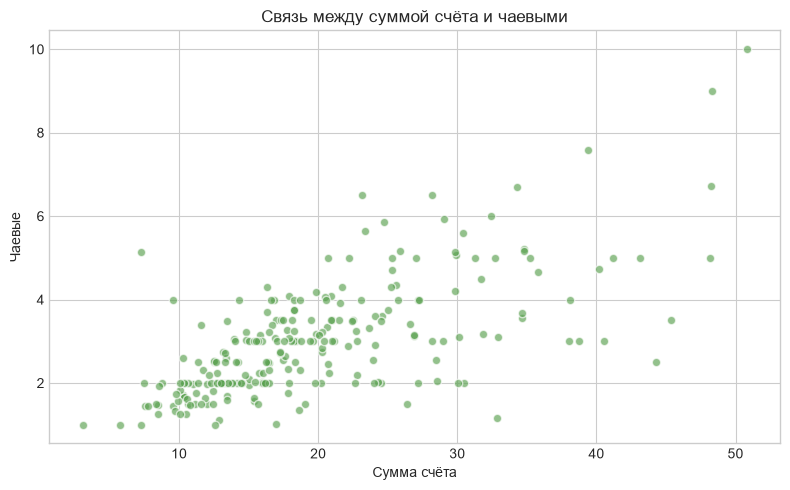

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df["total_bill"],
    df["tip"],
    alpha=0.65,
    color="#59A14F",
    edgecolor="white"
)

ax.set_title("Связь между суммой счёта и чаевыми")
ax.set_xlabel("Сумма счёта")
ax.set_ylabel("Чаевые")

plt.tight_layout()
plt.show()

In [11]:
mean_bill = df["total_bill"].mean()
median_bill = df["total_bill"].median()
weekend_share = df["day"].isin(["Sat", "Sun"]).mean() * 100
bill_tip_correlation = df[["total_bill", "tip"]].corr().loc["total_bill", "tip"]

print(f"Средний счёт: {mean_bill:.2f}")
print(f"Медианный счёт: {median_bill:.2f}")
print(f"Доля посещений в выходные: {weekend_share:.1f}%")
print(f"Корреляция суммы счёта и чаевых: {bill_tip_correlation:.2f}")

Средний счёт: 19.79
Медианный счёт: 17.80
Доля посещений в выходные: 66.8%
Корреляция суммы счёта и чаевых: 0.68


## Выводы

1. Небольшие счета встречаются чаще. Крупных счетов меньше, поэтому на гистограмме справа получился длинный хвост примерно до 50.

2. На субботу и воскресенье приходится 66,8% записей. Больше всего записей за субботу, меньше всего за пятницу. Это соотношение в нашей выборке, по нему нельзя судить о загрузке ресторана в целом.

3. При большем счёте чаевые обычно тоже больше. Корреляция равна примерно 0,68. При этом точки на графике разбросаны: при похожих счетах чаевые могут заметно отличаться.